# Proyecto Final DL — Fase 1

Este notebook cubre únicamente:
1. Selección y documentación del dataset.
2. EDA completo.
3. Definición de modelo MLP base.
4. Métricas de evaluación.

> En esta fase **no** se entrena ni se hace clasificación final.

## Dataset seleccionado
- Fuente: Kaggle
- Nombre: **Skin Diseases Cancer Comprehensive Dataset**
- Croissant JSON-LD:
  https://www.kaggle.com/datasets/anieetorudofia/skin-diseases-cancer-comprehensive-dataset/croissant/download

Este dataset es principalmente de **imágenes**, por lo que el análisis se hará por archivos/etiquetas de carpetas y metadatos de imagen (no por tabla tabular).

In [ ]:
import json
from pathlib import Path
import mlcroissant as mlc
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from PIL import Image

In [ ]:
# Asignacion de variables
DATASET_URL = (
    "https://www.kaggle.com/datasets/anieetorudofia/"
    "skin-diseases-cancer-comprehensive-dataset/croissant/download"
)

KAGGLE_DATASET_SLUG = "anieetorudofia/skin-diseases-cancer-comprehensive-dataset"

#Configuración de croissant y kagglehub
croissant_dataset = mlc.Dataset(DATASET_URL)
record_sets = croissant_dataset.metadata.record_sets

print("Record sets detectados:", len(record_sets))
if len(record_sets) > 0:
    for i, rs in enumerate(record_sets, start=1):
        print(f"{i}. name={getattr(rs, 'name', 'N/A')} | uuid={getattr(rs, 'uuid', 'N/A')}")
else:
    print("Croissant no expone records tabulares para este dataset (esperable si solo contiene imágenes).")

dataset_path = Path(kagglehub.dataset_download(KAGGLE_DATASET_SLUG))
print("Ruta local del dataset:", dataset_path)

  -  [Metadata(Skin Diseases + Cancer Comprehensive Dataset)] Property "http://mlcommons.org/croissant/citeAs" is recommended, but does not exist.


Record sets detectados: 0
Croissant no expone records tabulares para este dataset (esperable si solo contiene imágenes).
Ruta local del dataset: C:\Users\arani\.cache\kagglehub\datasets\anieetorudofia\skin-diseases-cancer-comprehensive-dataset\versions\7


In [ ]:
# Exploración de archivos de imagen para construir un DataFrame con metadatos

valid_ext = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

image_files = [
    p for p in dataset_path.rglob("*")
    if p.is_file() and p.suffix.lower() in valid_ext
]

images_df = pd.DataFrame({
    "file_path": [str(p) for p in image_files],
    "label": [p.parent.name for p in image_files],
    "ext": [p.suffix.lower() for p in image_files],
    "file_size_bytes": [p.stat().st_size for p in image_files],
})

print("Total de imágenes encontradas:", len(images_df))
print("Shape:", images_df.shape)
images_df.head()

Total de imágenes encontradas: 13034
Shape: (13034, 4)


,file_path,label,ext,file_size_bytes
0,C:\Users\arani\.cache\kagglehub\datasets\aniee...,Acne,.jpeg,85985
1,C:\Users\arani\.cache\kagglehub\datasets\aniee...,Acne,.jpeg,95923
2,C:\Users\arani\.cache\kagglehub\datasets\aniee...,Acne,.jpeg,99551
3,C:\Users\arani\.cache\kagglehub\datasets\aniee...,Acne,.jpeg,14141
4,C:\Users\arani\.cache\kagglehub\datasets\aniee...,Acne,.jpeg,12772


In [ ]:
# Función para leer metadatos de las imágenes, con manejo de errores

def read_image_metadata(path_str: str):
    try:
        with Image.open(path_str) as img:
            width, height = img.size
            mode = img.mode
        channels_map = {"L": 1, "RGB": 3, "RGBA": 4}
        channels = channels_map.get(mode, np.nan)
        return width, height, mode, channels, None
    except Exception as err:
        return np.nan, np.nan, None, np.nan, str(err)

# Aplicar la función a cada imagen y expandir los resultados en nuevas columnas
meta = images_df["file_path"].apply(read_image_metadata)
images_df[["width", "height", "mode", "channels", "read_error"]] = pd.DataFrame(meta.tolist(), index=images_df.index)
images_df["aspect_ratio"] = images_df["width"] / images_df["height"]
images_df["file_size_kb"] = images_df["file_size_bytes"] / 1024

images_df.head()

,file_path,label,ext,file_size_bytes,width,height,mode,channels,read_error,aspect_ratio,file_size_kb
0,C:\Users\arani\.cache\kagglehub\datasets\aniee...,Acne,.jpeg,85985,720,472,RGB,3.0,None,1.525424,83.969727
1,C:\Users\arani\.cache\kagglehub\datasets\aniee...,Acne,.jpeg,95923,720,472,RGB,3.0,None,1.525424,93.674805
2,C:\Users\arani\.cache\kagglehub\datasets\aniee...,Acne,.jpeg,99551,720,472,RGB,3.0,None,1.525424,97.217773
3,C:\Users\arani\.cache\kagglehub\datasets\aniee...,Acne,.jpeg,14141,294,222,RGB,3.0,None,1.324324,13.809570
4,C:\Users\arani\.cache\kagglehub\datasets\aniee...,Acne,.jpeg,12772,294,222,RGB,3.0,None,1.324324,12.472656


In [ ]:
# Copia del DataFrame para análisis exploratorio de datos (EDA) y limpieza

df = images_df.copy()

print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])
print("Duplicados por ruta:", df.duplicated(subset=["file_path"]).sum())
print("Errores de lectura:", df["read_error"].notna().sum())

display(df.dtypes.to_frame("dtype"))
display(df.isna().sum().to_frame("missing").sort_values("missing", ascending=False))

Filas: 13034
Columnas: 11
Duplicados por ruta: 0
Errores de lectura: 0


,dtype
file_path,object
label,object
ext,object
file_size_bytes,int64
width,int64
height,int64
mode,object
channels,float64
read_error,object
aspect_ratio,float64


,missing
read_error,13034
channels,1
file_path,0
label,0
ext,0
file_size_bytes,0
width,0
height,0
mode,0
aspect_ratio,0


In [ ]:
# Análisis exploratorio de datos (EDA) básico para entender la distribución de metadatos

numeric_cols = ["file_size_kb", "width", "height", "channels", "aspect_ratio"]
categorical_cols = ["label", "ext", "mode"]

print("Columnas numéricas:", numeric_cols)
print("Columnas categóricas:", categorical_cols)

display(df[numeric_cols].describe().T)

print("\nTop 20 clases por cantidad:")
display(df["label"].value_counts().head(20).to_frame("count"))

print("\nDistribución de extensiones:")
display(df["ext"].value_counts().to_frame("count"))

print("\nDistribución de modo de color:")
display(df["mode"].value_counts(dropna=False).to_frame("count"))

Columnas numéricas: ['file_size_kb', 'width', 'height', 'channels', 'aspect_ratio']
Columnas categóricas: ['label', 'ext', 'mode']


,count,mean,std,min,25%,50%,75%,max
file_size_kb,13034.0,97.332892,356.643912,1.124023,52.724121,83.367188,104.388916,20430.052734
width,13034.0,609.975372,309.240926,100.000000,477.000000,720.000000,720.000000,8688.000000
height,13034.0,491.488568,239.961862,73.000000,450.000000,473.000000,512.000000,5792.000000
channels,13033.0,3.000000,0.000000,3.000000,3.000000,3.000000,3.000000,3.000000
aspect_ratio,13034.0,1.303401,0.339302,0.357333,1.323077,1.484536,1.525424,3.610169



Top 20 clases por cantidad:


,count
label,
Benign_tumors,1094
Eczema,1016
Tinea,926
Psoriasis,835
Actinic_Keratosis,750
Vitiligo,714
Acne,600
Warts,589
Lichen,568



Distribución de extensiones:


,count
ext,
.jpeg,11590
.jpg,1443
.png,1



Distribución de modo de color:


,count
mode,
RGB,13033
P,1


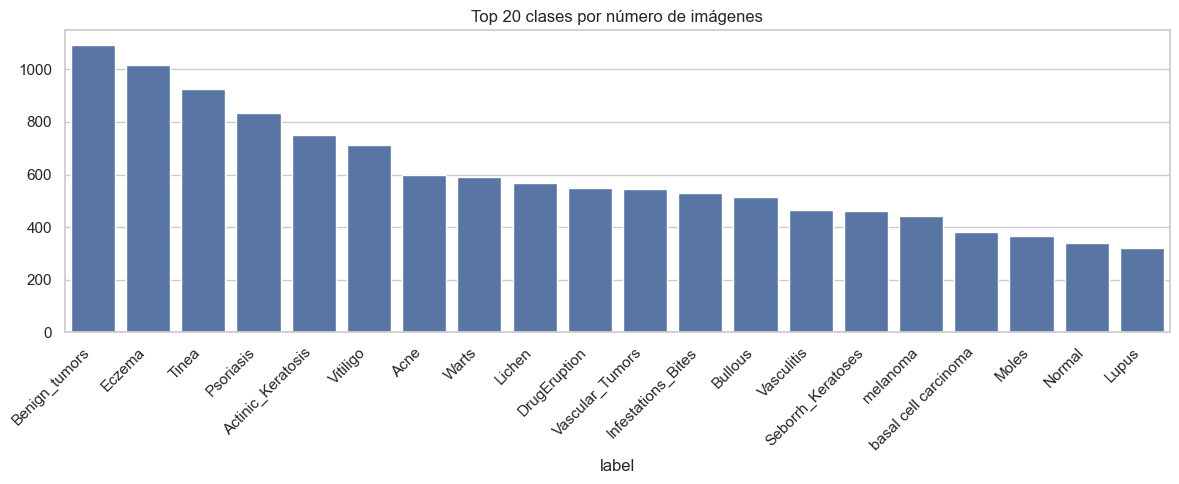

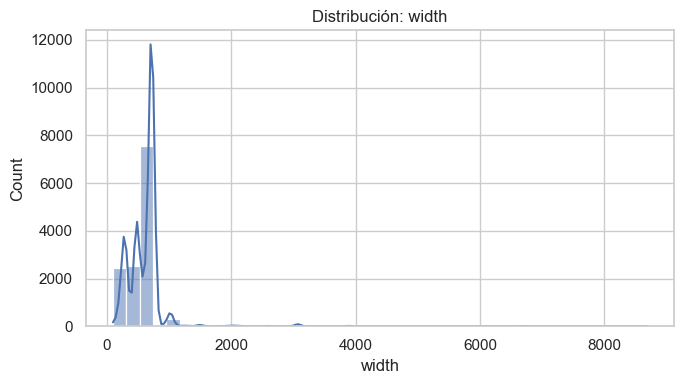

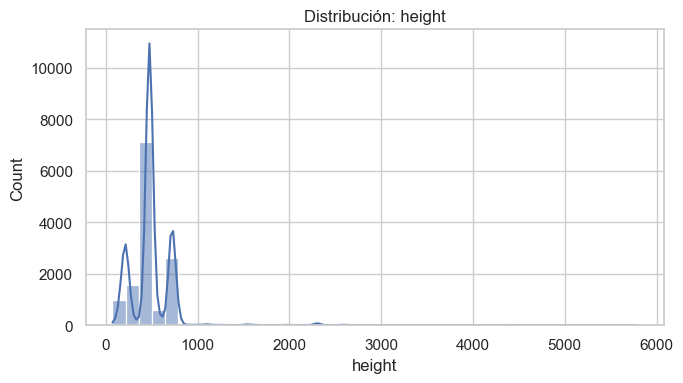

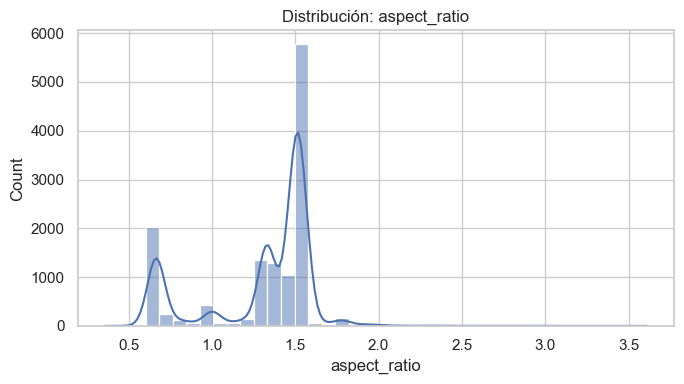

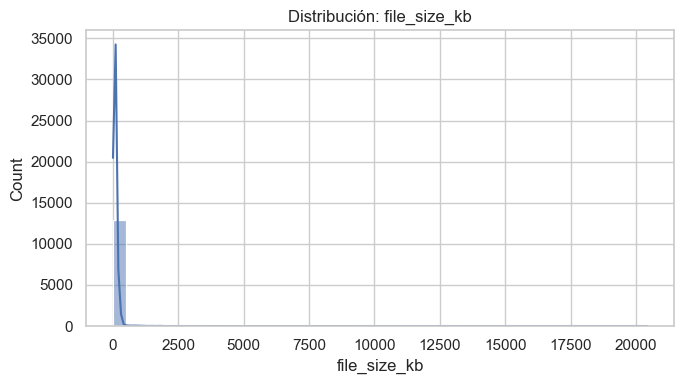

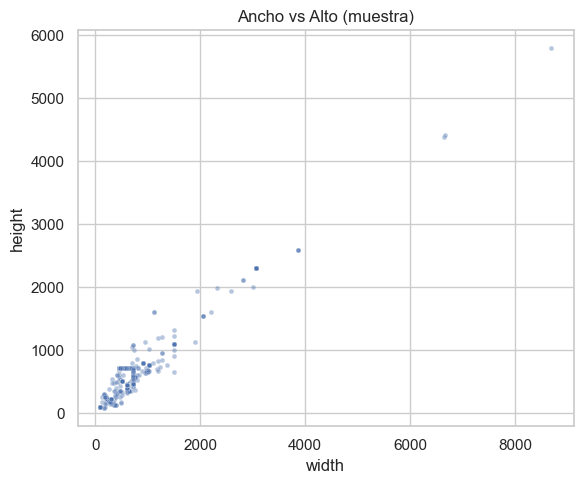

In [ ]:
# Visualizaciones para entender mejor la distribución de clases y metadatos

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 5))
class_counts = df["label"].value_counts().head(20)
sns.barplot(x=class_counts.index.astype(str), y=class_counts.values)
plt.title("Top 20 clases por número de imágenes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

for col in ["width", "height", "aspect_ratio", "file_size_kb"]:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col].dropna(), bins=40, kde=True)
    plt.title(f"Distribución: {col}")
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(6, 5))
sample_for_scatter = df[["width", "height"]].dropna().sample(min(5000, len(df)), random_state=42)
sns.scatterplot(data=sample_for_scatter, x="width", y="height", s=12, alpha=0.4)
plt.title("Ancho vs Alto (muestra)")
plt.tight_layout()
plt.show()

In [ ]:
# Generación de un documento Markdown con la documentación del dataset basada en el análisis realizado

output_dir = Path("reports")
output_dir.mkdir(parents=True, exist_ok=True)

doc_lines = [
    "# Documentación del Dataset (Imágenes)",
    "",
    "## Fuente",
    f"- URL Croissant: {DATASET_URL}",
    f"- Kaggle slug: {KAGGLE_DATASET_SLUG}",
    f"- Ruta local: {dataset_path}",
    "",
    "## Inventario de imágenes",
    f"- Total imágenes: {len(df)}",
    f"- Número de clases (carpeta padre): {df['label'].nunique()}",
    f"- Extensiones detectadas: {', '.join(sorted(df['ext'].dropna().unique()))}",
    f"- Modos detectados: {', '.join(sorted(df['mode'].dropna().astype(str).unique()))}",
    "",
    "## Calidad de datos",
    f"- Errores de lectura de imagen: {df['read_error'].notna().sum()}",
    f"- Duplicados por ruta: {df.duplicated(subset=['file_path']).sum()}",
    "",
    "## Recomendaciones previas al entrenamiento",
    "- Validar desbalance de clases y usar class_weight si aplica.",
    "- Estandarizar tamaño de entrada (ej. 128x128 o 224x224).",
    "- Definir split estratificado train/val/test por clase.",
    "- Añadir data augmentation solo en entrenamiento."
]

doc_path = output_dir / "dataset_documentation.md"
doc_path.write_text('\n'.join(doc_lines), encoding="utf-8")
print(f"Documento generado en: {doc_path}")

Documento generado en: reports\dataset_documentation.md


In [ ]:
# Construcción de un modelo MLP básico para clasificación de imágenes, con configuración de hiperparámetros

# Función para construir un modelo MLP básico para clasificación de imágenes
def build_base_mlp_image(input_shape=(128, 128, 3), num_classes: int = 2, learning_rate: float = 1e-3):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Rescaling(1.0 / 255.0),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(512, activation="relu"),
        tf.keras.layers.Dropout(0.30),
        tf.keras.layers.Dense(256, activation="relu"),
        tf.keras.layers.Dropout(0.20),
        tf.keras.layers.Dense(num_classes, activation="softmax"),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=[
            tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
            tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top_3_accuracy"),
        ],
    )
    return model

# Instanciación del modelo MLP solo si se detectan 2 o más clases en el dataset
num_classes = int(df["label"].nunique())
print("Número de clases detectadas:", num_classes)

if num_classes >= 2:
    mlp_base = build_base_mlp_image(input_shape=(128, 128, 3), num_classes=num_classes)
    mlp_base.summary()
else:
    print("No se instancia el MLP automáticamente porque se detectó menos de 2 clases.")

Número de clases detectadas: 24


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    25,166,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,303,832 (96.53 MB)

 Trainable params: 25,303,832 (96.53 MB)

 Non-trainable params: 0 (0.00 B)

## Métricas de evaluación definidas
- `accuracy` (SparseCategoricalAccuracy)
- `top_3_accuracy` (SparseTopKCategoricalAccuracy)

Cuando pases a entrenamiento, puedes agregar:
- Precision, Recall, F1 macro
- Matriz de confusión
- Curvas ROC-AUC por clase (one-vs-rest)